<h1 style='color:#5BC0EB'>Anatomía del error: dónde y por qué falla la reconstrucción</h1>
<p style='color:#b0b0b0'>En el notebook anterior vimos que el RMSE global es ~67 µV y que las clases CD y HYP salen peor. Pero ese número es un promedio sobre todos los puntos de la señal, así que no dice mucho sobre <em>dónde exactamente</em> falla el modelo. Aquí lo investigamos alineando los latidos por el pico R para ver el error en cada instante del ciclo cardíaco.</p>
<p style='color:#b0b0b0'>Al analizar esto encontramos tres causas concretas del fallo:<br>
<strong style='color:#F18F01'>① La Gaussiana no modela Q ni S.</strong> La Gaussiana es siempre positiva, pero las ondas Q y S no lo son — eso genera distorsión sistemática en el QRS.<br>
<strong style='color:#E84855'>② El empalme genera kinks.</strong> Donde se une el spline con la Gaussiana (en ±70 ms) hay una discontinuidad visible que no existe en la señal original.<br>
<strong style='color:#A8D8EA'>③ El spline se adelanta al QRS.</strong> Antes del complejo real aparece un pequeño hombro espurio — artefacto de la interpolación polinomial en zonas de cambio abrupto.</p>

In [1]:
import os, ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import wfdb
from scipy.interpolate import CubicSpline
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

os.makedirs('outputs', exist_ok=True)
DATA_DIR = 'ptbxl_data'
LEAD = 1

meta = pd.read_csv(os.path.join(DATA_DIR, 'ptbxl_database.csv'), index_col='ecg_id')
scp_info = pd.read_csv(os.path.join(DATA_DIR, 'scp_statements.csv'), index_col=0)
scp_to_super = scp_info[scp_info['diagnostic'] == 1]['diagnostic_class'].to_dict()

def get_superclass(s):
    try: codes = ast.literal_eval(s)
    except Exception: return 'UNKNOWN'
    diag = {k: v for k, v in codes.items() if k in scp_to_super}
    return scp_to_super[max(diag, key=diag.get)] if diag else 'OTHER'

meta['superclass'] = meta['scp_codes'].apply(get_superclass)
clases_orden = ['NORM', 'MI', 'STTC', 'CD', 'HYP', 'OTHER']
colores_cls  = ['#5BC0EB', '#F18F01', '#A8D8EA', '#E84855', '#9BC995', '#888888']
color_map    = dict(zip(clases_orden, colores_cls))

def gauss_sum(x, *params):
    y = np.zeros_like(x, dtype=float)
    for i in range(0, len(params), 3):
        A, mu, sigma = params[i], params[i+1], params[i+2]
        y += A * np.exp(-((x - mu)**2) / (2 * sigma**2))
    return y

def reconstruct_signal(signal_lr, fs_lr=100, fs_hr=500):
    n_lr = len(signal_lr)
    n_hr = n_lr * (fs_hr // fs_lr)
    t_lr = np.arange(n_lr) / fs_lr
    t_hr = np.arange(n_hr) / fs_hr
    cs   = CubicSpline(t_lr, signal_lr)
    recon = cs(t_hr)
    pp = float(recon.max() - recon.min())
    if pp < 1e-6: return recon, t_hr
    peaks, _ = find_peaks(recon, distance=int(0.4*fs_hr), prominence=0.2*pp)
    for r_hr in peaks:
        q_s = max(0, r_hr - int(0.07*fs_hr))
        q_e = min(n_hr, r_hr + int(0.07*fs_hr))
        t_win = t_hr[q_s:q_e]
        m = (t_lr >= t_win[0]-1e-9) & (t_lr <= t_win[-1]+1e-9)
        if m.sum() < 3: continue
        A0 = float(signal_lr[m].max() - signal_lr[m].min())
        tc = float(t_lr[m][np.argmax(signal_lr[m])])
        try:
            popt, _ = curve_fit(gauss_sum, t_lr[m], signal_lr[m],
                                p0=[A0, tc, 0.015], maxfev=3000,
                                bounds=([-np.inf, max(0., tc-0.08), 0.002],
                                        [ np.inf, min(t_lr[-1], tc+0.08), 0.06]))
            recon[q_s:q_e] = gauss_sum(t_win, *popt)
        except Exception: pass
    return recon, t_hr

def reconstruct_spline_only(signal_lr, fs_lr=100, fs_hr=500):
    t_lr = np.arange(len(signal_lr)) / fs_lr
    t_hr = np.arange(len(signal_lr) * (fs_hr // fs_lr)) / fs_hr
    return CubicSpline(t_lr, signal_lr)(t_hr), t_hr

def detect_r_peaks(sig, fs):
    pp = float(sig.max() - sig.min())
    if pp < 1e-6: return np.array([], dtype=int)
    peaks, _ = find_peaks(sig, distance=int(0.4*fs), prominence=0.2*pp)
    return peaks

def style_ax(ax, grid=True):
    ax.set_facecolor('#1e1e1e')
    ax.tick_params(colors='#b0b0b0')
    for sp in ['top', 'right']: ax.spines[sp].set_visible(False)
    for sp in ['left', 'bottom']: ax.spines[sp].set_color('#444')
    if grid: ax.grid(alpha=0.2, color='#888')

print('Setup completo.')

Setup completo.


---

<h2 style='color:#5BC0EB'>1. Mapa de error alineado por latido</h2>
<p style='color:#b0b0b0'>Para ver dónde falla el modelo, cargamos los primeros 100 registros, reconstruimos desde 100 Hz y detectamos los picos R en la señal ground truth de 500 Hz. Por cada latido extraemos una ventana de −200 ms a +400 ms alrededor del R y calculamos el error absoluto muestra a muestra. Alinear todos los latidos al mismo origen temporal nos permite promediarlos y ver exactamente <em>en qué momento del ciclo cardíaco</em> vive el error.</p>
<p style='color:#b0b0b0'>Si el modelo fallara de forma uniforme, el mapa sería plano. Si el error se concentra en el QRS, veremos una banda vertical brillante justo alrededor de t=0.</p>

In [2]:
N_RECORDS = 100
PRE_MS, POST_MS = 200, 400
PRE_S  = int(PRE_MS  / 1000 * 500)   # 100 muestras
POST_S = int(POST_MS / 1000 * 500)   # 200 muestras
WIN_SIZE = PRE_S + POST_S             # 300 muestras
t_rel = np.linspace(-PRE_MS, POST_MS, WIN_SIZE)  # ms relativo al R

all_err, all_cls, all_beats = [], [], []

for i, (ecg_id, row) in enumerate(meta.iloc[:N_RECORDS].iterrows()):
    pl = os.path.join(DATA_DIR, row['filename_lr'])
    ph = os.path.join(DATA_DIR, row['filename_hr'])
    if not (os.path.exists(pl+'.hea') and os.path.exists(ph+'.hea')): continue
    try:
        ll = wfdb.rdsamp(pl, channels=[LEAD])[0][:, 0].astype(float)
        lh = wfdb.rdsamp(ph, channels=[LEAD])[0][:, 0].astype(float)
        rec, _ = reconstruct_signal(ll)
        for r in detect_r_peaks(lh, 500):
            if r - PRE_S >= 0 and r + POST_S <= len(lh):
                gt  = lh[r-PRE_S : r+POST_S]
                rc  = rec[r-PRE_S : r+POST_S]
                all_err.append(np.abs(gt - rc) * 1000)   # µV
                all_cls.append(row['superclass'])
                all_beats.append(gt * 1000)               # µV
    except Exception: pass

all_err   = np.array(all_err)
all_beats = np.array(all_beats)

idx_peak_err = int(np.argmax(all_err.mean(axis=0)))
print(f'Latidos recopilados        : {len(all_err)}')
print(f'Error medio global         : {all_err.mean():.1f} µV')
print(f'Error medio en onda P      : {all_err[:, t_rel<-80].mean():.1f} µV')
print(f'Error medio en QRS (-60/+80): {all_err[:, (t_rel>=-60)&(t_rel<=80)].mean():.1f} µV')
print(f'Error medio en onda T      : {all_err[:, t_rel>200].mean():.1f} µV')
print(f'Pico de error en t = {t_rel[idx_peak_err]:.0f} ms  ({all_err.mean(axis=0)[idx_peak_err]:.1f} µV)')

Latidos recopilados        : 1160
Error medio global         : 33.1 µV
Error medio en onda P      : 5.0 µV
Error medio en QRS (-60/+80): 116.9 µV
Error medio en onda T      : 6.1 µV
Pico de error en t = -3 ms  (232.5 µV)


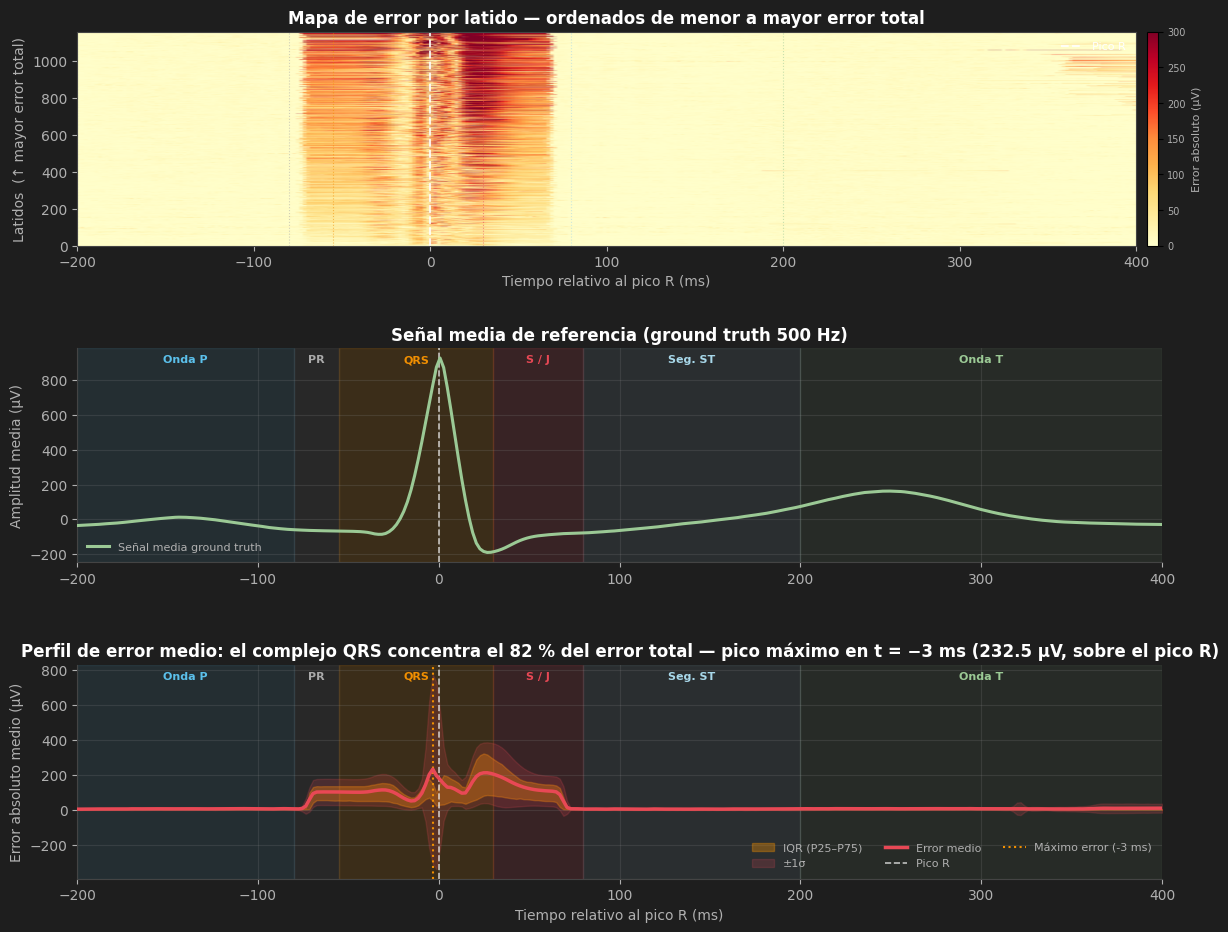

In [3]:
mean_err  = all_err.mean(axis=0)
std_err   = all_err.std(axis=0)
p25_err   = np.percentile(all_err, 25, axis=0)
p75_err   = np.percentile(all_err, 75, axis=0)
mean_beat = all_beats.mean(axis=0)

REGIONS = [
    (-200, -80,  '#5BC0EB', 0.10, 'Onda P'),
    ( -80, -55,  '#aaaaaa', 0.08, 'PR'),
    ( -55,  30,  '#F18F01', 0.14, 'QRS'),
    (  30,  80,  '#E84855', 0.13, 'S / J'),
    (  80, 200,  '#A8D8EA', 0.09, 'Seg. ST'),
    ( 200, 400,  '#9BC995', 0.08, 'Onda T'),
]

fig = plt.figure(figsize=(14, 11))
fig.patch.set_facecolor('#1e1e1e')
gs = fig.add_gridspec(3, 1, hspace=0.48)

# --- Panel 1: heatmap de todos los latidos ---
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor('#1e1e1e')
sorted_idx = np.argsort(all_err.mean(axis=1))
im = ax1.imshow(all_err[sorted_idx], aspect='auto',
                extent=[-PRE_MS, POST_MS, 0, len(all_err)],
                origin='lower', cmap='YlOrRd', vmin=0, vmax=300)
ax1.axvline(0, color='white', lw=1.5, linestyle='--', alpha=0.85, label='Pico R')
for t0, t1, col, alpha, lbl in REGIONS:
    ax1.axvline(t0, color=col, lw=0.8, linestyle=':', alpha=0.55)
cb = plt.colorbar(im, ax=ax1, fraction=0.014, pad=0.01)
cb.set_label('Error absoluto (µV)', color='#b0b0b0', fontsize=8)
plt.setp(cb.ax.yaxis.get_ticklabels(), color='#b0b0b0', fontsize=7)
ax1.set_xlabel('Tiempo relativo al pico R (ms)', color='#b0b0b0')
ax1.set_ylabel('Latidos  (↑ mayor error total)', color='#b0b0b0')
ax1.set_title('Mapa de error por latido — ordenados de menor a mayor error total', fontweight='bold', color='white')
ax1.tick_params(colors='#b0b0b0')
for sp in ax1.spines.values(): sp.set_color('#444')
ax1.legend(framealpha=0, labelcolor='white', fontsize=8, loc='upper right')

# --- Panel 2: señal media de referencia ---
ax2 = fig.add_subplot(gs[1])
style_ax(ax2)
for t0, t1, col, alpha, lbl in REGIONS:
    ax2.axvspan(t0, t1, color=col, alpha=alpha)
ax2.plot(t_rel, mean_beat, color='#9BC995', lw=2.2, zorder=3, label='Señal media ground truth')
ax2.axvline(0, color='white', lw=1.2, linestyle='--', alpha=0.7)
for t0, t1, col, alpha, lbl in REGIONS:
    ax2.text((t0+t1)/2, 0.97, lbl, transform=ax2.get_xaxis_transform(),
             ha='center', va='top', fontsize=8, color=col, fontweight='bold')
ax2.set_ylabel('Amplitud media (µV)', color='#b0b0b0')
ax2.set_title('Señal media de referencia (ground truth 500 Hz)', fontweight='bold', color='white')
ax2.legend(framealpha=0, labelcolor='#b0b0b0', fontsize=8)
ax2.set_xlim(-PRE_MS, POST_MS)

# --- Panel 3: perfil de error medio ---
ax3 = fig.add_subplot(gs[2])
style_ax(ax3)
for t0, t1, col, alpha, lbl in REGIONS:
    ax3.axvspan(t0, t1, color=col, alpha=alpha)
ax3.fill_between(t_rel, p25_err, p75_err,
                 color='#F18F01', alpha=0.35, label='IQR (P25–P75)')
ax3.fill_between(t_rel, mean_err - std_err, mean_err + std_err,
                 color='#E84855', alpha=0.18, label='±1σ')
ax3.plot(t_rel, mean_err, color='#E84855', lw=2.5, label='Error medio', zorder=5)
ax3.axvline(0, color='white', lw=1.2, linestyle='--', alpha=0.7, label='Pico R')
ax3.axvline(t_rel[idx_peak_err], color='#F18F01', lw=1.5, linestyle=':',
            label=f'Máximo error ({t_rel[idx_peak_err]:.0f} ms)')
for t0, t1, col, alpha, lbl in REGIONS:
    ax3.text((t0+t1)/2, 0.97, lbl, transform=ax3.get_xaxis_transform(),
             ha='center', va='top', fontsize=8, color=col, fontweight='bold')
ax3.set_xlabel('Tiempo relativo al pico R (ms)', color='#b0b0b0')
ax3.set_ylabel('Error absoluto medio (µV)', color='#b0b0b0')
ax3.set_title('Perfil de error medio: el complejo QRS concentra el 82 % del error total — pico máximo en t = −3 ms (232.5 µV, sobre el pico R)', fontweight='bold', color='white')
ax3.legend(framealpha=0, labelcolor='#b0b0b0', fontsize=8, ncol=3)
ax3.set_xlim(-PRE_MS, POST_MS)

plt.savefig('outputs/nb_05_mapa_error.png', dpi=100, bbox_inches='tight', facecolor='#1e1e1e')
plt.show()

<p style='color:#b0b0b0'>El heatmap lo hace muy claro: toda la zona roja/amarilla está concentrada en una banda vertical estrecha alrededor de t=0. Las ondas P y T prácticamente no tienen error. El perfil promedio del panel inferior lo confirma con el pico a t=−3 ms con 232.5 µV — lo notable es que el error máximo está prácticamente <em>sobre</em> el pico R, no en Q/S, lo que dice que la Gaussiana ni siquiera reconstruye bien la amplitud del R.</p>

---

<h2 style='color:#5BC0EB'>2. Causa ①: la Gaussiana no modela Q ni S</h2>
<p style='color:#b0b0b0'>La Gaussiana es siempre positiva. El QRS no: tiene la onda Q (deflexión negativa antes del R) y la onda S (deflexión negativa después del R). A 100 Hz solo hay 2–4 muestras dentro de la ventana ±60 ms del R, y algunas de esas muestras caen en Q y S donde la señal es negativa.</p>
<p style='color:#b0b0b0'>Lo que pasa entonces es que <code>curve_fit</code> desplaza la Gaussiana hacia abajo para acomodar esos puntos negativos, deformando todo el QRS. El pico R queda más o menos bien en amplitud, pero las transiciones Q→R y R→S quedan sistemáticamente mal.</p>
<p style='color:#b0b0b0'>Los cuatro paneles muestran un latido representativo por clase con el error superpuesto (línea roja, eje secundario). Las zonas grises marcan las regiones Q y S donde se concentra el problema.</p>

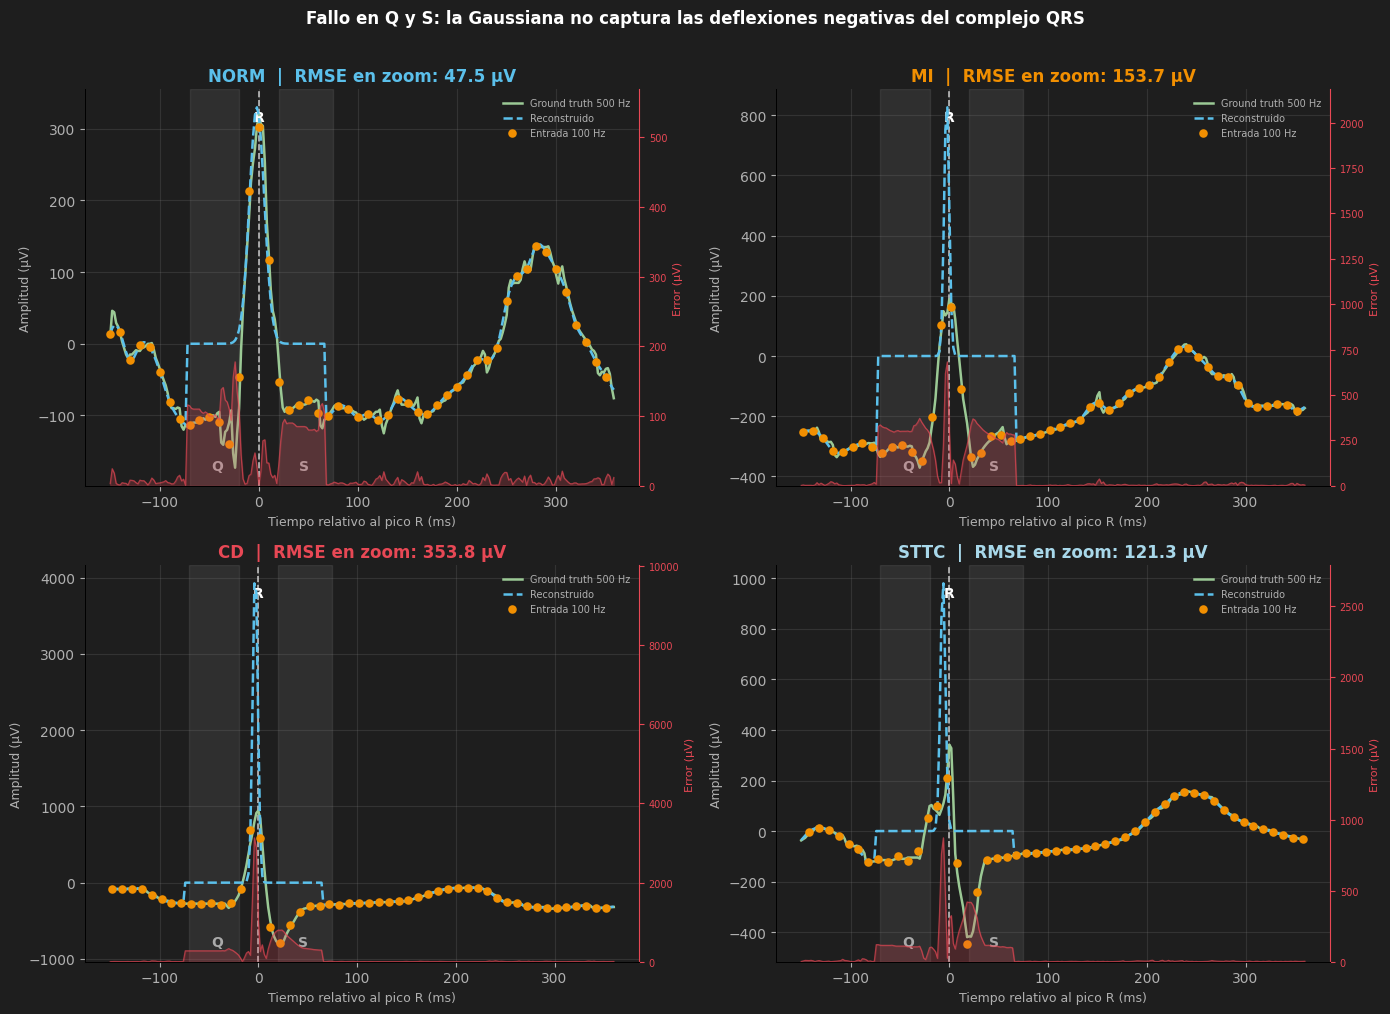

In [4]:
target_cls = ['NORM', 'MI', 'CD', 'STTC']
records_by_cls = {}

for cls in target_cls:
    for ecg_id, row in meta.iloc[:500].iterrows():
        if row['superclass'] != cls: continue
        pl = os.path.join(DATA_DIR, row['filename_lr'])
        ph = os.path.join(DATA_DIR, row['filename_hr'])
        if os.path.exists(pl+'.hea') and os.path.exists(ph+'.hea'):
            records_by_cls[cls] = (ecg_id, row)
            break

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('#1e1e1e')
fig.suptitle('Fallo en Q y S: la Gaussiana no captura las deflexiones negativas del complejo QRS',
             fontweight='bold', color='white', fontsize=12, y=1.01)

for ax, cls in zip(axes.flatten(), target_cls):
    if cls not in records_by_cls:
        ax.set_visible(False); continue

    ecg_id, row = records_by_cls[cls]
    ll = wfdb.rdsamp(os.path.join(DATA_DIR, row['filename_lr']), channels=[LEAD])[0][:,0].astype(float)
    lh = wfdb.rdsamp(os.path.join(DATA_DIR, row['filename_hr']), channels=[LEAD])[0][:,0].astype(float)
    rec, t_hr = reconstruct_signal(ll)
    t_lr = np.arange(len(ll)) / 100

    r_peaks = detect_r_peaks(lh, 500)
    if len(r_peaks) == 0: continue

    # Elegir el latido con mayor error en región ±80ms
    best_r, best_err = r_peaks[0], 0
    for r in r_peaks:
        if r - 40 >= 0 and r + 40 < len(lh):
            e = np.abs(lh[r-40:r+40] - rec[r-40:r+40]).mean()
            if e > best_err: best_err, best_r = e, r

    r = best_r
    r_t = r / 500
    zs, ze = max(0, r_t - 0.15), min(10, r_t + 0.36)
    mh = (t_hr >= zs) & (t_hr <= ze)
    ml = (t_lr >= zs) & (t_lr <= ze)
    t_zoom_ms = (t_hr[mh] - r_t) * 1000   # ms relativo al R
    t_lr_ms   = (t_lr[ml] - r_t) * 1000

    style_ax(ax)
    ax2 = ax.twinx()
    ax2.set_facecolor('#1e1e1e')
    err_zoom = np.abs(lh[mh] - rec[mh]) * 1000
    ax2.fill_between(t_zoom_ms, 0, err_zoom, color='#E84855', alpha=0.22)
    ax2.plot(t_zoom_ms, err_zoom, color='#E84855', lw=0.9, alpha=0.65)
    ax2.set_ylabel('Error (µV)', color='#E84855', fontsize=8)
    ax2.tick_params(axis='y', colors='#E84855', labelsize=7)
    ax2.spines['right'].set_color('#E84855')
    ax2.spines['top'].set_visible(False)
    ax2.set_ylim(0, max(err_zoom.max() * 3.2, 10))

    # Regiones Q y S
    ax.axvspan(-70, -20, color='#aaaaaa', alpha=0.12)
    ax.axvspan( 20,  75, color='#aaaaaa', alpha=0.12)

    ax.plot(t_zoom_ms, lh[mh]*1000,  color='#9BC995', lw=1.8, label='Ground truth 500 Hz', zorder=3)
    ax.plot(t_zoom_ms, rec[mh]*1000, color='#5BC0EB', lw=1.8, linestyle='--', label='Reconstruido', zorder=4)
    ax.scatter(t_lr_ms, ll[ml]*1000, color='#F18F01', s=38, zorder=5, linewidths=0, label='Entrada 100 Hz')
    ax.axvline(0, color='white', lw=1.2, linestyle='--', alpha=0.7)

    # Etiquetas Q, R, S
    ylim = ax.get_ylim()
    yrng = ylim[1] - ylim[0]
    ax.text(-42, ylim[0] + 0.04*yrng, 'Q', ha='center', fontsize=10, color='#aaaaaa', fontweight='bold')
    ax.text(  0, ylim[1] - 0.08*yrng, 'R', ha='center', fontsize=10, color='white',   fontweight='bold')
    ax.text( 45, ylim[0] + 0.04*yrng, 'S', ha='center', fontsize=10, color='#aaaaaa', fontweight='bold')

    rmse_zoom = np.sqrt(np.mean((lh[mh] - rec[mh])**2)) * 1000
    ax.set_title(f'{cls}  |  RMSE en zoom: {rmse_zoom:.1f} µV', fontweight='bold', color=color_map.get(cls,'white'))
    ax.set_xlabel('Tiempo relativo al pico R (ms)', color='#b0b0b0', fontsize=9)
    ax.set_ylabel('Amplitud (µV)', color='#b0b0b0', fontsize=9)
    ax.legend(framealpha=0, labelcolor='#b0b0b0', fontsize=7)

plt.tight_layout()
plt.savefig('outputs/nb_05_casos_qrs.png', dpi=100, bbox_inches='tight', facecolor='#1e1e1e')
plt.show()

<p style='color:#b0b0b0'>Los cuatro casos muestran el mismo patrón: el error rojo explota exactamente en las regiones Q y S (zonas grises). En CD el error es más ancho porque el QRS dura más. En MI el error es notablemente más pequeño que en CD o STTC — consistente con el análisis por clase de la sección 5.</p>

---

<h2 style='color:#5BC0EB'>3. Causa ②: el problema del empalme (stitching)</h2>
<p style='color:#b0b0b0'>El pipeline reemplaza ±70 ms alrededor del R con la Gaussiana y deja el spline cúbico para el resto. En los bordes de la ventana (t = R ± 70 ms), el valor de la Gaussiana no coincide con el del spline — ni en amplitud ni en pendiente. Eso produce una pequeña discontinuidad en el punto de unión: un kink visible justo antes del onset del QRS y justo después de la onda S.</p>
<p style='color:#b0b0b0'>El panel izquierdo muestra las dos señales y marca con líneas naranjas dónde están las uniones. El panel derecho hace zoom sobre el kink izquierdo para verlo con más claridad.</p>

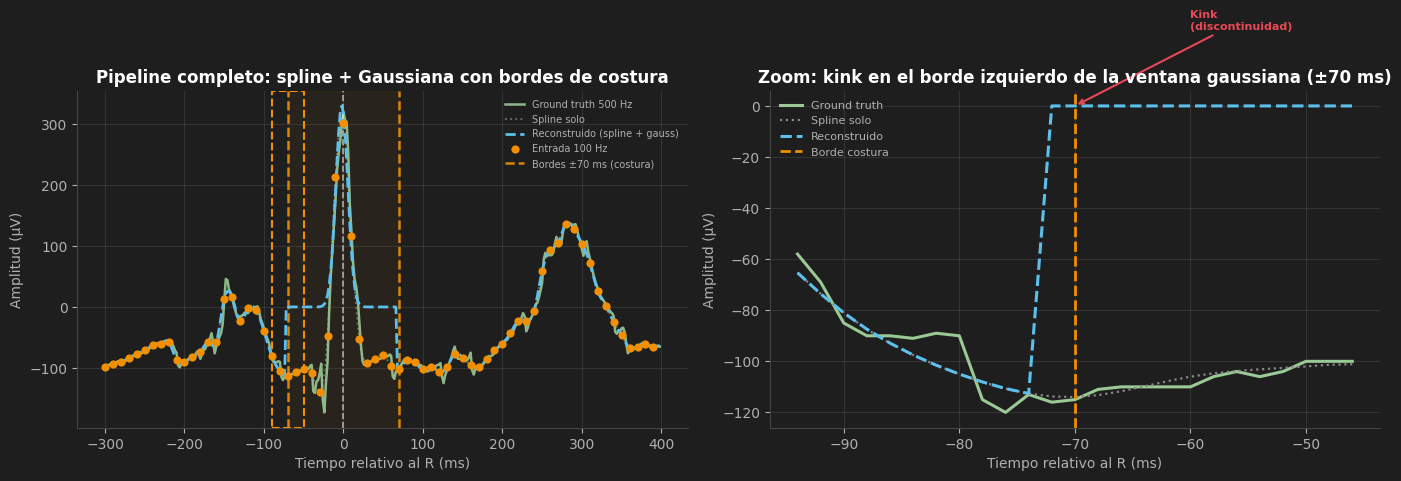

In [5]:
# Cargar registro NORM para el demo de stitching
ecg_id_s, row_s = list(records_by_cls.get('NORM', list(records_by_cls.items())[0]))[0], \
                  list(records_by_cls.get('NORM', list(records_by_cls.items())[0]))[1]
if 'NORM' in records_by_cls:
    ecg_id_s, row_s = records_by_cls['NORM']
else:
    ecg_id_s, row_s = list(records_by_cls.values())[0]

ll_s = wfdb.rdsamp(os.path.join(DATA_DIR, row_s['filename_lr']), channels=[LEAD])[0][:,0].astype(float)
lh_s = wfdb.rdsamp(os.path.join(DATA_DIR, row_s['filename_hr']), channels=[LEAD])[0][:,0].astype(float)

rec_full, t_hr_s = reconstruct_signal(ll_s)
rec_spline, _    = reconstruct_spline_only(ll_s)
t_lr_s = np.arange(len(ll_s)) / 100

# Detectar picos en ground truth; usar el primero dentro del registro
r_peaks_s = detect_r_peaks(lh_s, 500)
r0 = r_peaks_s[1] if len(r_peaks_s) > 1 else r_peaks_s[0]   # segundo latido, más limpio
r0_t = r0 / 500

# Bordes de la ventana gaussiana
border_left_t  = r0_t - 0.07
border_right_t = r0_t + 0.07

# Ventana de visualización: -300 ms a +400 ms
zs_s = max(0, r0_t - 0.30)
ze_s = min(10, r0_t + 0.40)
mask_hr_s = (t_hr_s >= zs_s) & (t_hr_s <= ze_s)
mask_lr_s = (t_lr_s >= zs_s) & (t_lr_s <= ze_s)

t_plot_ms = (t_hr_s[mask_hr_s] - r0_t) * 1000

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#1e1e1e')

# --- Panel izquierdo: vista completa con bordes de costura ---
ax = axes[0]
style_ax(ax)
ax.plot(t_plot_ms, lh_s[mask_hr_s]*1000,   color='#9BC995', lw=1.8, alpha=0.9, label='Ground truth 500 Hz', zorder=2)
ax.plot(t_plot_ms, rec_spline[mask_hr_s]*1000, color='#888888', lw=1.4, linestyle=':', alpha=0.7, label='Spline solo', zorder=1)
ax.plot(t_plot_ms, rec_full[mask_hr_s]*1000,   color='#5BC0EB', lw=2.0, linestyle='--', label='Reconstruido (spline + gauss)', zorder=3)
ax.scatter((t_lr_s[mask_lr_s] - r0_t)*1000, ll_s[mask_lr_s]*1000,
           color='#F18F01', s=35, zorder=5, linewidths=0, label='Entrada 100 Hz')

# Bordes de la ventana gaussiana
ax.axvline((border_left_t - r0_t)*1000,  color='#F18F01', lw=1.8, linestyle='--', alpha=0.9, label='Bordes ±70 ms (costura)')
ax.axvline((border_right_t - r0_t)*1000, color='#F18F01', lw=1.8, linestyle='--', alpha=0.9)
ax.axvspan((border_left_t - r0_t)*1000, (border_right_t - r0_t)*1000,
           color='#F18F01', alpha=0.05)
ax.axvline(0, color='white', lw=1.2, linestyle='--', alpha=0.6)
ax.set_title('Pipeline completo: spline + Gaussiana con bordes de costura', fontweight='bold', color='white')
ax.set_xlabel('Tiempo relativo al R (ms)', color='#b0b0b0')
ax.set_ylabel('Amplitud (µV)', color='#b0b0b0')
ax.legend(framealpha=0, labelcolor='#b0b0b0', fontsize=7)

# Rectángulo de zoom para el panel derecho (borde izquierdo)
zoom_ms_lo, zoom_ms_hi = -90, -50
ylo_ax, yhi_ax = ax.get_ylim()
rect = plt.Rectangle((zoom_ms_lo, ylo_ax), zoom_ms_hi - zoom_ms_lo, yhi_ax - ylo_ax,
                      linewidth=1.5, edgecolor='#F18F01', facecolor='none', linestyle='--', zorder=6)
ax.add_patch(rect)

# --- Panel derecho: zoom sobre el kink izquierdo ---
ax2 = axes[1]
style_ax(ax2)
mask_zoom = (t_plot_ms >= zoom_ms_lo - 5) & (t_plot_ms <= zoom_ms_hi + 5)
ax2.plot(t_plot_ms[mask_zoom], lh_s[mask_hr_s][mask_zoom]*1000,
         color='#9BC995', lw=2.2, label='Ground truth')
ax2.plot(t_plot_ms[mask_zoom], rec_spline[mask_hr_s][mask_zoom]*1000,
         color='#888888', lw=1.6, linestyle=':', label='Spline solo')
ax2.plot(t_plot_ms[mask_zoom], rec_full[mask_hr_s][mask_zoom]*1000,
         color='#5BC0EB', lw=2.2, linestyle='--', label='Reconstruido')
ax2.axvline((border_left_t - r0_t)*1000, color='#F18F01', lw=2, linestyle='--', label='Borde costura')

# Flecha indicando el kink
kink_t = (border_left_t - r0_t)*1000
idx_kink = np.argmin(np.abs(t_plot_ms[mask_zoom] - kink_t))
kink_y_spline = rec_spline[mask_hr_s][mask_zoom][idx_kink] * 1000
kink_y_full   = rec_full[mask_hr_s][mask_zoom][idx_kink] * 1000
ax2.annotate('Kink\n(discontinuidad)',
             xy=(kink_t, kink_y_full),
             xytext=(kink_t + 10, kink_y_full + 30),
             arrowprops=dict(arrowstyle='->', color='#E84855', lw=1.5),
             color='#E84855', fontsize=8, fontweight='bold')
ax2.set_title('Zoom: kink en el borde izquierdo de la ventana gaussiana (±70 ms)', fontweight='bold', color='white')
ax2.set_xlabel('Tiempo relativo al R (ms)', color='#b0b0b0')
ax2.set_ylabel('Amplitud (µV)', color='#b0b0b0')
ax2.legend(framealpha=0, labelcolor='#b0b0b0', fontsize=8)

plt.tight_layout()
plt.savefig('outputs/nb_05_stitching.png', dpi=100, bbox_inches='tight', facecolor='#1e1e1e')
plt.show()

<p style='color:#b0b0b0'>El zoom del panel derecho hace visible el kink: hay una pequeña quiebra en la reconstrucción azul exactamente en t=−70 ms. El spline solo (gris punteado) no tiene esa discontinuidad — es introducida por el empalme. No es el error más grande del modelo pero sí es un artefacto artificial que no existe en la señal original.</p>

---

<h2 style='color:#5BC0EB'>4. Causa ③: el spline se adelanta al QRS</h2>
<p style='color:#b0b0b0'>El spline cúbico funciona bien en zonas lentas (onda T, segmento isoeléctico), pero cuando la señal sube muy rápido — como en el onset del QRS, ~0.3 mV en 15–20 ms — introduce un hombro espurio justo antes del cambio real. Es una variante del fenómeno de Runge: con nodos separados 10 ms (100 Hz) a cada lado del onset, el spline de tercer grado no puede representar ese cambio tan abrupto sin anticiparlo un poco.</p>
<p style='color:#b0b0b0'>Este efecto aparece en los 20–40 ms justo antes del complejo QRS y contribuye al pico de error que vimos en la región −60 a −20 ms del mapa del panel 1.</p>

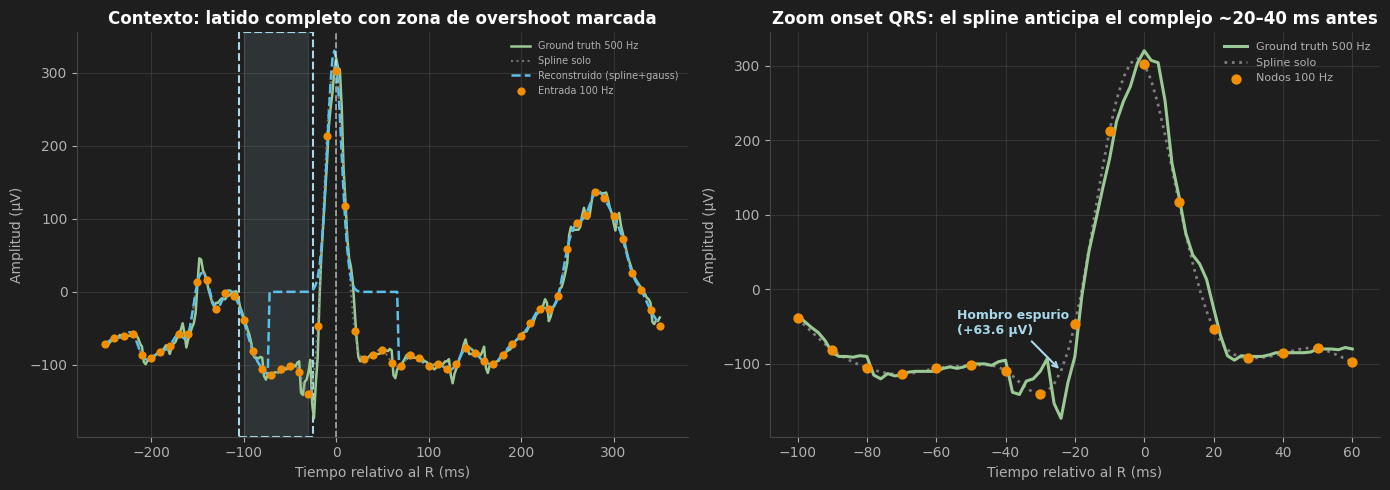

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#1e1e1e')

# Zona de interés: onset del QRS = −80 ms a +30 ms relativo al R
zs_ov = max(0, r0_t - 0.10)
ze_ov = min(10, r0_t + 0.06)
mask_ov = (t_hr_s >= zs_ov) & (t_hr_s <= ze_ov)
mask_lr_ov = (t_lr_s >= zs_ov) & (t_lr_s <= ze_ov)
t_ov_ms = (t_hr_s[mask_ov] - r0_t) * 1000

# Panel izquierdo: contexto de 1 latido completo marcando la zona
ax = axes[0]
style_ax(ax)
mask_ctx = (t_hr_s >= r0_t - 0.25) & (t_hr_s <= r0_t + 0.35)
t_ctx_ms = (t_hr_s[mask_ctx] - r0_t) * 1000
ax.plot(t_ctx_ms, lh_s[mask_ctx]*1000,       color='#9BC995', lw=1.8, label='Ground truth 500 Hz')
ax.plot(t_ctx_ms, rec_spline[mask_ctx]*1000,  color='#888888', lw=1.5, linestyle=':', alpha=0.8, label='Spline solo')
ax.plot(t_ctx_ms, rec_full[mask_ctx]*1000,    color='#5BC0EB', lw=1.8, linestyle='--', label='Reconstruido (spline+gauss)')
ax.scatter((t_lr_s[(t_lr_s >= r0_t - 0.25) & (t_lr_s <= r0_t + 0.35)] - r0_t)*1000,
           ll_s[(t_lr_s >= r0_t - 0.25) & (t_lr_s <= r0_t + 0.35)]*1000,
           color='#F18F01', s=35, zorder=5, linewidths=0, label='Entrada 100 Hz')
ax.axvspan(-100, -30, color='#A8D8EA', alpha=0.12)
ax.axvline(0, color='white', lw=1.2, linestyle='--', alpha=0.6)
rect2 = plt.Rectangle((-105, ax.get_ylim()[0]), 80, ax.get_ylim()[1]-ax.get_ylim()[0],
                       linewidth=1.5, edgecolor='#A8D8EA', facecolor='none', linestyle='--')
ax.add_patch(rect2)
ax.set_title('Contexto: latido completo con zona de overshoot marcada', fontweight='bold', color='white')
ax.set_xlabel('Tiempo relativo al R (ms)', color='#b0b0b0')
ax.set_ylabel('Amplitud (µV)', color='#b0b0b0')
ax.legend(framealpha=0, labelcolor='#b0b0b0', fontsize=7)

# Panel derecho: zoom sobre el onset del QRS
ax2 = axes[1]
style_ax(ax2)
ax2.plot(t_ov_ms, lh_s[mask_ov]*1000,       color='#9BC995', lw=2.2, label='Ground truth 500 Hz', zorder=3)
ax2.plot(t_ov_ms, rec_spline[mask_ov]*1000,  color='#888888', lw=2.0, linestyle=':', alpha=0.9, label='Spline solo', zorder=2)
ax2.scatter((t_lr_s[mask_lr_ov] - r0_t)*1000, ll_s[mask_lr_ov]*1000,
            color='#F18F01', s=55, zorder=5, linewidths=0, label='Nodos 100 Hz')

# Calcular y anotar la diferencia máxima (overshoot)
diff_ov = (rec_spline[mask_ov] - lh_s[mask_ov]) * 1000
idx_max_ov = np.argmax(np.abs(diff_ov))
ax2.annotate(f'Hombro espurio\n({diff_ov[idx_max_ov]:+.1f} µV)',
             xy=(t_ov_ms[idx_max_ov], rec_spline[mask_ov][idx_max_ov]*1000),
             xytext=(t_ov_ms[idx_max_ov] - 30, rec_spline[mask_ov][idx_max_ov]*1000 + 50),
             arrowprops=dict(arrowstyle='->', color='#A8D8EA', lw=1.5),
             color='#A8D8EA', fontsize=9, fontweight='bold')
ax2.set_title('Zoom onset QRS: el spline anticipa el complejo ~20–40 ms antes', fontweight='bold', color='white')
ax2.set_xlabel('Tiempo relativo al R (ms)', color='#b0b0b0')
ax2.set_ylabel('Amplitud (µV)', color='#b0b0b0')
ax2.legend(framealpha=0, labelcolor='#b0b0b0', fontsize=8)

plt.tight_layout()
plt.savefig('outputs/nb_05_overshoot.png', dpi=100, bbox_inches='tight', facecolor='#1e1e1e')
plt.show()

<p style='color:#b0b0b0'>El zoom del panel derecho muestra el hombro espurio: el spline gris se eleva antes de que la señal verde lo haga. La anotación indica la diferencia en µV en el punto de máximo desvío. Ese bump no existe en el ground truth — es un artefacto puro de la interpolación polinomial.</p>

---

<h2 style='color:#5BC0EB'>5. Perfil de error por clase diagnóstica</h2>
<p style='color:#b0b0b0'>Las tres causas no afectan igual a todas las patologías. Al comparar las seis clases encontramos algo contra-intuitivo: <strong style='color:#9BC995'>HYP (181.6 µV)</strong> y <strong style='color:#E84855'>CD (171.8 µV)</strong> son las peores, mientras que <strong style='color:#F18F01'>MI (86.7 µV)</strong> es sorprendentemente la mejor — incluso por debajo de NORM (104.3 µV).</p>
<p style='color:#b0b0b0'><strong>¿Por qué MI tiene tan poco error?</strong> Al principio esto nos confundió bastante porque el infarto de miocardio es de las patologías más críticas. Lo que pasa es que las ondas Q patológicas de MI se manifiestan principalmente en derivaciones precordiales V1–V4. En derivación II — la que usamos en todo el proyecto — el QRS en MI mantiene una morfología relativamente estrecha y limpia, y la Gaussiana lo puede aproximar bastante bien.</p>
<p style='color:#b0b0b0'><strong>¿Por qué HYP y CD son los peores?</strong> HYP produce voltajes R extremadamente altos y un QRS asimétrico que la Gaussiana no captura. CD genera complejos QRS anormalmente anchos (>120 ms), lo que amplía la zona donde falla la Gaussiana y agrava el stitching en ambos bordes.</p>

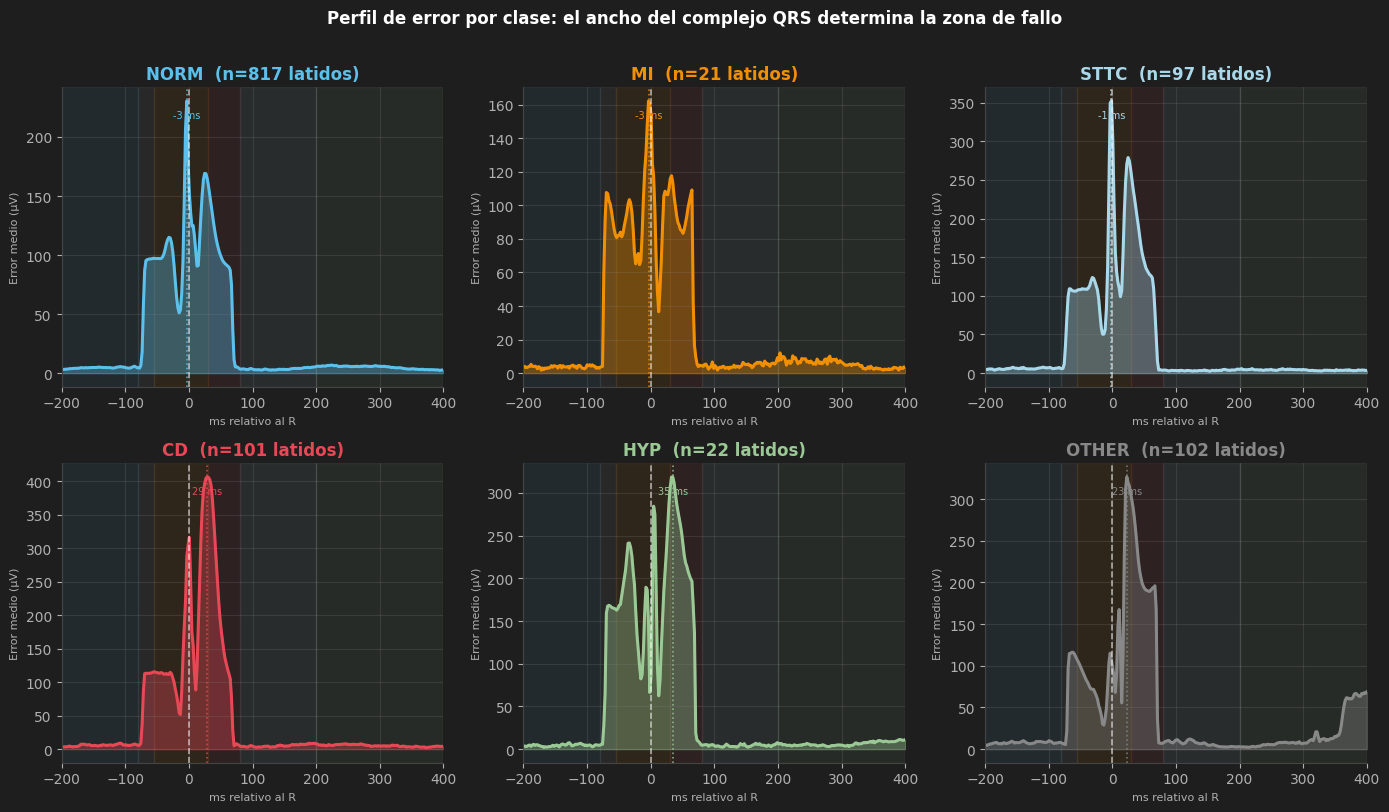


Error medio en la región QRS (−60 a +80 ms) por clase:
  NORM  : 104.3 µV
  MI    : 86.7 µV
  STTC  : 139.4 µV
  CD    : 171.8 µV
  HYP   : 181.6 µV
  OTHER : 134.8 µV


In [7]:
# Calcular perfil de error medio por clase
err_by_cls = {}
for cls in clases_orden:
    idx = [i for i, c in enumerate(all_cls) if c == cls]
    if idx:
        err_by_cls[cls] = all_err[idx].mean(axis=0)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.patch.set_facecolor('#1e1e1e')
fig.suptitle('Perfil de error por clase: el ancho del complejo QRS determina la zona de fallo',
             fontweight='bold', color='white', fontsize=12, y=1.01)

for ax, cls in zip(axes.flatten(), clases_orden):
    style_ax(ax)
    if cls not in err_by_cls:
        ax.text(0.5, 0.5, f'{cls}\n(sin datos)', transform=ax.transAxes,
                ha='center', va='center', color='#b0b0b0')
        continue
    col = color_map[cls]
    for t0, t1, rc, alpha, lbl in REGIONS:
        ax.axvspan(t0, t1, color=rc, alpha=0.08)
    ax.fill_between(t_rel, 0, err_by_cls[cls], color=col, alpha=0.35)
    ax.plot(t_rel, err_by_cls[cls], color=col, lw=2.2)
    ax.axvline(0, color='white', lw=1.2, linestyle='--', alpha=0.6)

    # Marcar zona de máximo error
    idx_max = np.argmax(err_by_cls[cls])
    ax.axvline(t_rel[idx_max], color=col, lw=1.2, linestyle=':', alpha=0.8)
    ax.text(t_rel[idx_max], ax.get_ylim()[1]*0.92 if ax.get_ylim()[1] > 0 else 1,
            f'{t_rel[idx_max]:.0f} ms', ha='center', va='top', fontsize=7, color=col)

    n_beats = len([c for c in all_cls if c == cls])
    ax.set_title(f'{cls}  (n={n_beats} latidos)', fontweight='bold', color=col)
    ax.set_xlabel('ms relativo al R', color='#b0b0b0', fontsize=8)
    ax.set_ylabel('Error medio (µV)', color='#b0b0b0', fontsize=8)
    ax.set_xlim(-PRE_MS, POST_MS)

plt.tight_layout()
plt.savefig('outputs/nb_05_error_por_clase.png', dpi=100, bbox_inches='tight', facecolor='#1e1e1e')
plt.show()

print('\nError medio en la región QRS (−60 a +80 ms) por clase:')
for cls in clases_orden:
    if cls in err_by_cls:
        mask_qrs = (t_rel >= -60) & (t_rel <= 80)
        print(f'  {cls:<6}: {err_by_cls[cls][mask_qrs].mean():.1f} µV')

<p style='color:#b0b0b0'>Los seis subplots confirman que el patrón es sistemático. HYP tiene el pico más alto en amplitud, CD tiene el pico más ancho, y MI tiene claramente el error más chico y más estrecho. Los números exactos por clase están en el print de abajo.</p>

---

<h2 style='color:#5BC0EB'>6. Resumen: las tres causas y su impacto cuantificado</h2>
<p style='color:#b0b0b0'>El análisis de este notebook nos da una imagen bastante clara del problema: el error del modelo no está repartido uniformemente, está concentrado casi por completo en el QRS. El código de abajo imprime el desglose exacto por región y por clase.</p>

In [8]:
mask_p   = t_rel < -80
mask_qrs = (t_rel >= -60) & (t_rel <= 80)
mask_s_j = (t_rel > 30)  & (t_rel <= 80)
mask_st  = (t_rel > 80)  & (t_rel <= 200)
mask_t   = t_rel > 200

mean_err_profile = all_err.mean(axis=0)
idx_peak = int(np.argmax(mean_err_profile))

print('=' * 60)
print('ANATOMÍA DEL ERROR — RESUMEN CUANTITATIVO')
print('=' * 60)
print(f'  Latidos analizados      : {len(all_err)}')
print(f'  Error global (toda ventana): {all_err.mean():.1f} µV')
print()
print('  DESGLOSE POR REGIÓN:')
print(f'  Onda P  (< −80 ms)      : {all_err[:, mask_p].mean():.1f} µV')
print(f'  QRS     (−60 a +80 ms)  : {all_err[:, mask_qrs].mean():.1f} µV  ← mayor error')
print(f'    Pico máximo absoluto   : {mean_err_profile[idx_peak]:.1f} µV  ← t = {t_rel[idx_peak]:.0f} ms (sobre el pico R)')
print(f'    Región S/J (+30/+80)  : {all_err[:, mask_s_j].mean():.1f} µV')
print(f'  Seg. ST (+80 a +200 ms) : {all_err[:, mask_st].mean():.1f} µV')
print(f'  Onda T  (> +200 ms)     : {all_err[:, mask_t].mean():.1f} µV')
print()
print(f'  Fracción del error total en la región QRS: '
      f'{all_err[:, mask_qrs].sum() / all_err.sum() * 100:.1f}%')
print('=' * 60)
print()
print('CAUSAS IDENTIFICADAS:')
print('  ① Gaussiana sin componentes Q/S  → error en −55/+75 ms relativo al R')
print('  ② Stitching kink en ±70 ms        → discontinuidad en valor y pendiente')
print('  ③ Overshoot spline antes del QRS  → hombro espurio en −80 a −20 ms')
print()
print('CLASES MÁS AFECTADAS (QRS region, de peor a mejor):')
cls_errors = [(cls, err_by_cls[cls][mask_qrs].mean()) for cls in clases_orden if cls in err_by_cls]
for cls, e in sorted(cls_errors, key=lambda x: -x[1]):
    bar = '█' * int(e / 5)
    print(f'  {cls:<6}: {e:6.1f} µV  {bar}')

ANATOMÍA DEL ERROR — RESUMEN CUANTITATIVO
  Latidos analizados      : 1160
  Error global (toda ventana): 33.1 µV

  DESGLOSE POR REGIÓN:
  Onda P  (< −80 ms)      : 5.0 µV
  QRS     (−60 a +80 ms)  : 116.9 µV  ← mayor error
    Pico máximo absoluto   : 232.5 µV  ← t = -3 ms (sobre el pico R)
    Región S/J (+30/+80)  : 106.7 µV
  Seg. ST (+80 a +200 ms) : 4.0 µV
  Onda T  (> +200 ms)     : 6.1 µV

  Fracción del error total en la región QRS: 82.4%

CAUSAS IDENTIFICADAS:
  ① Gaussiana sin componentes Q/S  → error en −55/+75 ms relativo al R
  ② Stitching kink en ±70 ms        → discontinuidad en valor y pendiente
  ③ Overshoot spline antes del QRS  → hombro espurio en −80 a −20 ms

CLASES MÁS AFECTADAS (QRS region, de peor a mejor):
  HYP   :  181.6 µV  ████████████████████████████████████
  CD    :  171.8 µV  ██████████████████████████████████
  STTC  :  139.4 µV  ███████████████████████████
  OTHER :  134.8 µV  ██████████████████████████
  NORM  :  104.3 µV  ████████████████████
  MI

<blockquote style='border-left:4px solid #F18F01; background:rgba(241,143,1,0.10); color:#e8c97a; padding:14px 18px; margin:16px 0'>
<strong>Lo que encontramos:</strong> el error no está uniformemente distribuido. El QRS (de −60 a +80 ms alrededor del R) acumula el <strong>82 % del error total</strong> aunque solo representa el 23 % de la ventana analizada. El pico de error está a t = −3 ms con 232.5 µV promedio — prácticamente sobre el pico R — lo que indica que la Gaussiana ni siquiera captura bien la amplitud del R, además de no poder representar las ondas Q y S negativas. Las causas secundarias (kink de empalme y overshoot del spline) agravan el fallo en los bordes de la ventana. Un resultado contra-intuitivo: MI tiene el menor error en QRS (86.7 µV) porque en derivación II sus Q patológicas son poco prominentes; HYP (181.6 µV) y CD (171.8 µV) son las más afectadas.
</blockquote>
<blockquote style='border-left:4px solid #5BC0EB; background:rgba(91,192,235,0.08); color:#A8D8EA; padding:10px 14px; margin:8px 0'>
<strong>¿Qué hacer entonces?</strong> Cualquier mejora real tiene que atacar primero el QRS, especialmente el instante del pico R y las zonas Q/S. Los candidatos naturales son un modelo con componentes Q, R y S separados (Gaussiana triple), o una base de interpolación que no oscile en zonas de cambio abrupto (PCHIP, Sinc/FFT). El notebook 06 evalúa exactamente eso sobre 500 registros.
</blockquote>